# Exploratory Data Analysis — Student Dropout Prediction

This notebook summarizes data quality, the target distribution, feature behavior, and correlations. Run from the `notebooks/` directory (paths assume `../data/raw/dataset.csv`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Allow imports from project package when running notebook from notebooks/
import sys
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.helpers import detect_target_column

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

DATA_PATH = ROOT / "data" / "raw" / "dataset.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,id,attendance_rate,gpa,age,num_failed_courses,parental_education,scholarship,internet_access,Dropout
0,1,85.656605,2.665685,19,1,High School,No,Yes,1
1,2,69.520191,2.945498,24,2,Unknown,No,Yes,1
2,3,91.005414,2.905944,26,2,High School,Partial,Yes,0
3,4,93.286777,2.149367,23,2,High School,No,Yes,0
4,5,58.587578,2.854294,21,1,High School,No,Yes,0


## 1. Basic analysis

In [2]:
print("Shape (rows, cols):", df.shape)
print("\nColumn names:")
print(list(df.columns))
print("\nData types:")
print(df.dtypes)

Shape (rows, cols): (220, 9)

Column names:
['id', 'attendance_rate', 'gpa', 'age', 'num_failed_courses', 'parental_education', 'scholarship', 'internet_access', 'Dropout']

Data types:
id                      int64
attendance_rate       float64
gpa                   float64
age                     int64
num_failed_courses      int64
parental_education        str
scholarship               str
internet_access           str
Dropout                 int64
dtype: object


In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
miss_df = miss_df[miss_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print("Missing values (only columns with any NaN):")
display(miss_df if len(miss_df) else "No missing values.")

Missing values (only columns with any NaN):


,missing_count,missing_pct
gpa,5,2.27
attendance_rate,3,1.36


In [4]:
uniq = pd.DataFrame({
    "n_unique": df.nunique(dropna=False),
    "example_values": [df[c].dropna().unique()[:5] for c in df.columns],
})
uniq

,n_unique,example_values
id,220,"[1, 2, 3, 4, 5]"
attendance_rate,209,"[85.65660495705318, 69.52019072511405, 91.0054..."
gpa,212,"[2.6656847098717003, 2.9454980747627326, 2.905..."
age,11,"[19, 24, 26, 23, 21]"
num_failed_courses,7,"[1, 2, 0, 3, 5]"
parental_education,4,"[High School, Unknown, Graduate, Bachelor]"
scholarship,3,"[No, Partial, Full]"
internet_access,2,"[Yes, No]"
Dropout,2,"[1, 0]"


## 2. Target analysis

In [5]:
target_col = detect_target_column(df.columns)
print(f"Inferred target column: {target_col!r}")

y = df[target_col]
counts = y.value_counts(dropna=False).sort_index()
props = y.value_counts(dropna=False, normalize=True).sort_index()
target_summary = pd.DataFrame({"count": counts, "proportion": props.round(4)})
print("\nClass distribution:")
display(target_summary)

minority_share = props.min()
if minority_share < 0.2:
    print("\nNote: minority class share < 20% — strong imbalance; use stratified CV, class weights, or resampling.")
elif minority_share < 0.35:
    print("\nNote: moderate imbalance — monitor precision/recall and consider class weights.")

Inferred target column: 'Dropout'

Class distribution:


,count,proportion
Dropout,,
0,145,0.6591
1,75,0.3409



Note: moderate imbalance — monitor precision/recall and consider class weights.


C:\Users\aryan\AppData\Local\Temp\ipykernel_29316\2633740430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, order=order, palette="Set2", ax=ax)


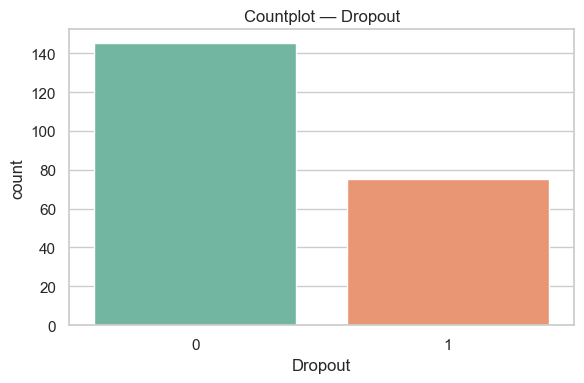

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
order = sorted(y.dropna().unique(), key=lambda v: str(v))
sns.countplot(data=df, x=target_col, order=order, palette="Set2", ax=ax)
ax.set_title(f"Countplot — {target_col}")
ax.set_xlabel(target_col)
plt.tight_layout()
plt.show()

## 3. Numerical features

In [7]:
feature_cols = [c for c in df.columns if c != target_col]
num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)
if num_cols:
    display(df[num_cols].describe().T)

Numeric columns: ['id', 'attendance_rate', 'gpa', 'age', 'num_failed_courses']


,count,mean,std,min,25%,50%,75%,max
id,220.0,110.500000,63.652704,1.000000,55.750000,110.500000,165.250000,220.0
attendance_rate,217.0,81.359052,10.118871,56.415445,74.056889,81.354609,88.517851,100.0
gpa,215.0,2.789410,0.607885,1.260005,2.381094,2.831480,3.201846,4.0
age,220.0,22.050000,3.058374,17.000000,19.750000,22.000000,24.250000,27.0
num_failed_courses,220.0,0.886364,1.011710,0.000000,0.000000,1.000000,1.000000,6.0


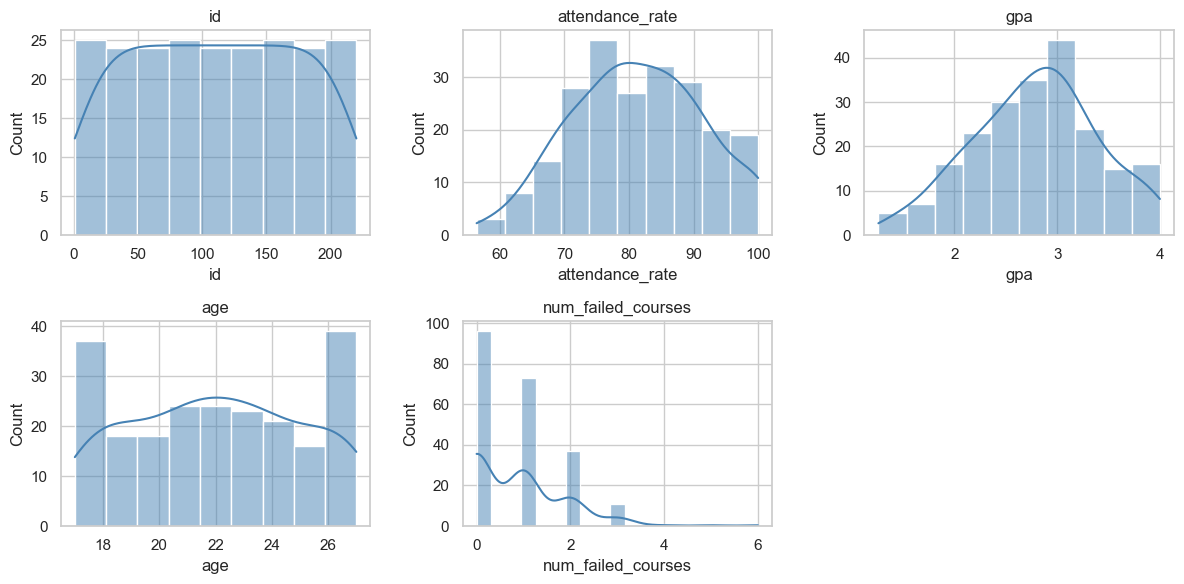

In [8]:
if num_cols:
    n = len(num_cols)
    fig, axes = plt.subplots(nrows=(n + 2) // 3, ncols=3, figsize=(12, 3 * ((n + 2) // 3)))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, num_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
        ax.set_title(col)
    for j in range(len(num_cols), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

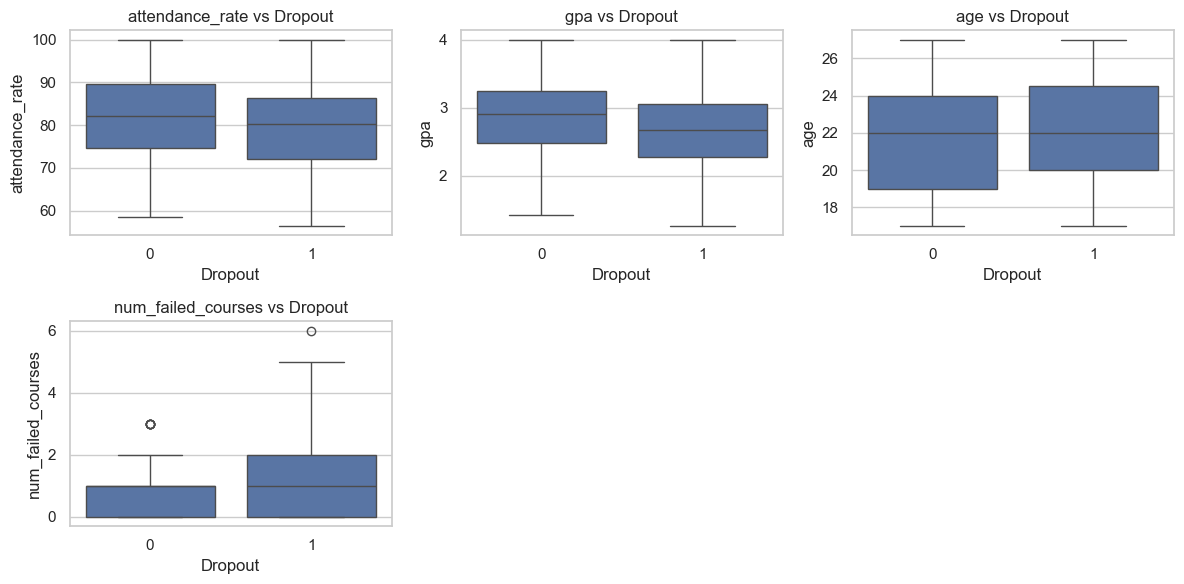

In [9]:
if num_cols:
    plot_cols = [c for c in num_cols if c.lower() != "id"]
    if plot_cols:
        fig, axes = plt.subplots(nrows=(len(plot_cols) + 2) // 3, ncols=3, figsize=(12, 3 * ((len(plot_cols) + 2) // 3)))
        axes = np.atleast_1d(axes).ravel()
        for ax, col in zip(axes, plot_cols):
            sns.boxplot(data=df, y=col, x=target_col, ax=ax)
            ax.set_title(f"{col} vs {target_col}")
        for j in range(len(plot_cols), len(axes)):
            axes[j].axis("off")
        plt.tight_layout()
        plt.show()

## 4. Categorical features

In [10]:
cat_cols = df[feature_cols].select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("Categorical columns:", cat_cols)

for col in cat_cols:
    print(f"\n--- {col} — value counts ---")
    display(df[col].value_counts(dropna=False))

Categorical columns: ['parental_education', 'scholarship', 'internet_access']

--- parental_education — value counts ---


C:\Users\aryan\AppData\Local\Temp\ipykernel_29316\2078780400.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df[feature_cols].select_dtypes(include=["object", "category", "bool"]).columns.tolist()


parental_education
High School    74
Bachelor       74
Graduate       49
Unknown        23
Name: count, dtype: int64


--- scholarship — value counts ---


scholarship
No         125
Partial     55
Full        40
Name: count, dtype: int64


--- internet_access — value counts ---


internet_access
Yes    187
No      33
Name: count, dtype: int64

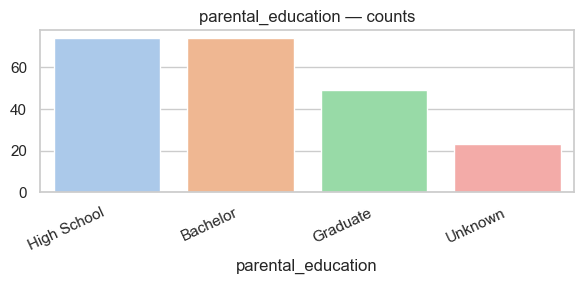

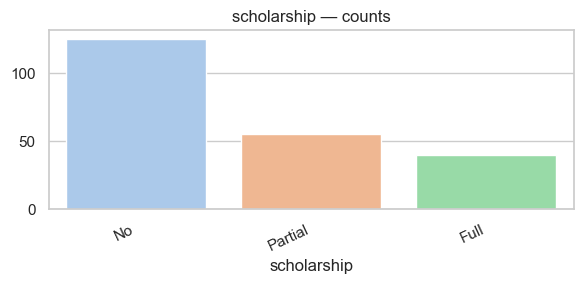

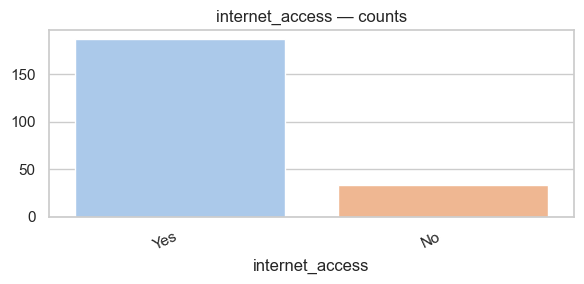

In [11]:
for col in cat_cols:
    vc = df[col].value_counts(dropna=False)
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.barplot(x=vc.index.astype(str), y=vc.values, ax=ax, hue=vc.index.astype(str), palette="pastel", legend=False)
    ax.set_title(f"{col} — counts")
    ax.set_xlabel(col)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

## 5. Correlation (numeric only)

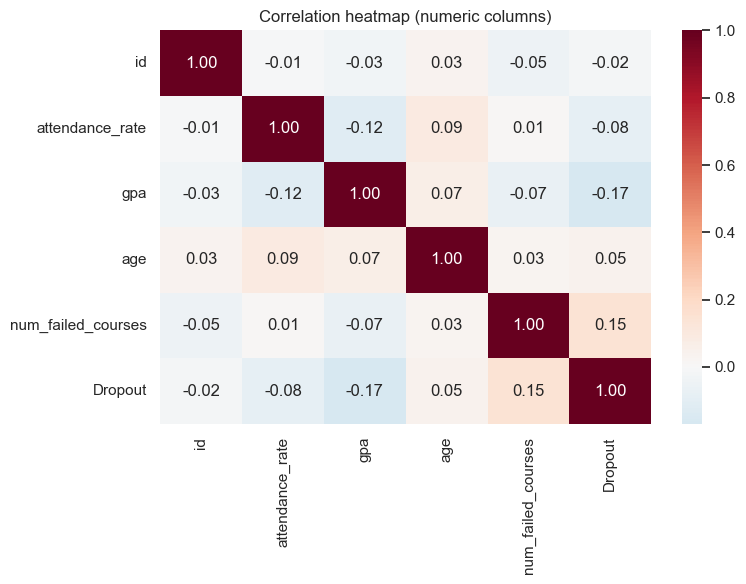

In [12]:
num_for_corr = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_for_corr) < 2:
    print("Not enough numeric columns for a meaningful correlation heatmap.")
else:
    corr = df[num_for_corr].corr(numeric_only=True)
    plt.figure(figsize=(max(8, len(num_for_corr) * 0.6), max(6, len(num_for_corr) * 0.5)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=False)
    plt.title("Correlation heatmap (numeric columns)")
    plt.tight_layout()
    plt.show()

## 6. Insights / conclusions

- **Target (`Dropout` or inferred name):** The countplot and class table show whether the problem is balanced. Moderate imbalance (e.g. ~30–40% minority) is common in dropout data; very small minority share would require special modeling choices.
- **Features linked to dropout (from boxplots and domain):** Lower **attendance** and **GPA**, higher **failed courses**, and **no internet access** often align with higher dropout risk in synthetic/real student data—verify on your actual dataset.
- **Numeric spread:** Histograms and boxplots highlight skewed grades/attendance and outliers (very low attendance or GPA) that trees and linear models may treat differently; scaling in the preprocessing pipeline helps distance-based models.
- **Categoricals:** Scholarship tier and parental education create distinct risk segments; one-hot encoding (with `handle_unknown='ignore'`) keeps the pipeline robust to unseen categories at inference.
- **Data quality:** Missing-value table shows where **mean / most-frequent imputation** will act (e.g. occasional missing GPA or attendance). No duplicate checks were run in this pass—add `df.duplicated().sum()` if IDs are unique.
- **Correlation:** Strong correlations among numerics (e.g. attendance vs GPA) suggest some redundancy; tree ensembles handle overlap well; linear models may benefit from regularization or feature selection later.

**Next steps:** Use `python main.py` (or import `run_training_pipeline`) to apply the fitted-on-train `ColumnTransformer`, save processed CSVs under `data/processed/`, and move on to model training (Phase 3).